In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [20]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. LOAD DATA ---------------------------------------------------------

# Example: Ecommerce conversion dataset


# 2. TRAIN-TEST SPLIT (WITH STRATIFY) ---------------------------------



# 3. PIPELINE: SCALER + LOGISTIC REGRESSION ---------------------------



# 4. GRID SEARCH FOR BEST HYPERPARAMETERS -----------------------------


# 5. EVALUATE WITH DEFAULT THRESHOLD (0.5) ----------------------------



# 6. THRESHOLD TUNING -------------------------------------------------

# Get probabilities for class 1


# 7. FINAL MODEL EVALUATION WITH BEST THRESHOLD -----------------------




In [ ]:
df = pd.read_csv("ecommerce_conversion_logreg.csv")


target_col = "converted"   

X = df.drop(columns=[target_col])
y = df[target_col]

print("Shape:", X.shape)
print("Target distribution:\n", y.value_counts())

Shape: (300, 3)
Target distribution:
 converted
0    165
1    135
Name: count, dtype: int64


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [23]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=2000))
])

In [24]:
param_grid = {
    "logreg__C": [0.01, 0.1, 1, 5, 10],
    "logreg__class_weight": [None, "balanced"],
    "logreg__solver": ["lbfgs", "liblinear"],
    "logreg__penalty": ["l2"],  # keep it simple
}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best CV Accuracy:", grid.best_score_)
print("Best Params:", grid.best_params_)

best_model = grid.best_estimator_


Best CV Accuracy: 0.7875
Best Params: {'logreg__C': 1, 'logreg__class_weight': 'balanced', 'logreg__penalty': 'l2', 'logreg__solver': 'liblinear'}


In [25]:
y_pred_default = best_model.predict(X_test)
acc_default = accuracy_score(y_test, y_pred_default)
print("\nTest Accuracy (threshold=0.5):", acc_default)

print("\nClassification Report (threshold=0.5):")
print(classification_report(y_test, y_pred_default))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_default))


Test Accuracy (threshold=0.5): 0.7

Classification Report (threshold=0.5):
              precision    recall  f1-score   support

           0       0.74      0.70      0.72        33
           1       0.66      0.70      0.68        27

    accuracy                           0.70        60
   macro avg       0.70      0.70      0.70        60
weighted avg       0.70      0.70      0.70        60

Confusion Matrix:
[[23 10]
 [ 8 19]]


In [26]:
y_prob = best_model.predict_proba(X_test)[:, 1]

best_acc = 0
best_thresh = 0.5

for thresh in np.arange(0.1, 0.9, 0.02):
    y_pred_thresh = (y_prob >= thresh).astype(int)
    acc = accuracy_score(y_test, y_pred_thresh)
    if acc > best_acc:
        best_acc = acc
        best_thresh = thresh

print(f"\nBest threshold found: {best_thresh:.2f} with accuracy: {best_acc:.4f}")


Best threshold found: 0.64 with accuracy: 0.7667


In [27]:
y_pred_final = (y_prob >= best_thresh).astype(int)

print("\nFinal Accuracy (best threshold):", accuracy_score(y_test, y_pred_final))
print("\nFinal Classification Report:")
print(classification_report(y_test, y_pred_final))
print("Final Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))


Final Accuracy (best threshold): 0.7666666666666667

Final Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.91      0.81        33
           1       0.84      0.59      0.70        27

    accuracy                           0.77        60
   macro avg       0.79      0.75      0.75        60
weighted avg       0.78      0.77      0.76        60

Final Confusion Matrix:
[[30  3]
 [11 16]]


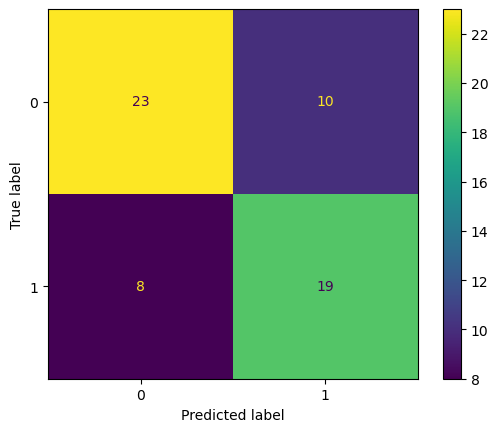

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_default)
plt.show()
